# 도로 영역을 찾자! - 세그멘테이션 모델 만들기 
* UNet 결과 및 UNet++결과는 최하단에 있습니다.

    각 모델의 학습은 
 Unet -> U-Net.ipynb
 Unet++ -> U-Net++.ipynb

으로 확인 할 수 있습니다.



*  U-Net++ 의 세그멘테이션 결과 사진과 IoU 계산치를 U-Net과 비교하여 우월함을 확인하였습니다.

* U-Net++ 모델을 스스로 구현하여 학습 진행 후 세그멘테이션 결과까지 정상 진행되었습니다.

* KITTI 데이터셋 구성, U-Net 모델 훈련, 결과물 시각화의 한 사이클이 정상 수행되어 세그멘테이션 결과 이미지를 제출하였습니다.

회고 : 

추가하자면 각 이미지당 정상적으로 나와야 하는 평균적인 학습100 에폭에 대한 iou 점수가 공개되어 있다면 좋았을 것으로 보임
unet++을 구현하고 LLM의 검사를 받아 해결하였지만 이에도 아직 궁금증이 남음



(triangle.png)[triangle.png](triangle.png)triangle.png
* 도로 위에 삼각형을 그려 삼각형에 대한 주요도값을 추가하여 iou값에 중요치를 가산

* 삼각형 부분에 iou가 높을수록 효과적인 모델로 확인함
roi: RoI(관심 영역) 내에서 계산된 겹침 정도를 IoU(교집합 비율)로 측정한다

In [1]:
#필요한 라이브러리를 로드합니다.
import os
import math
import numpy as np
import torch
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from glob import glob

import torch.nn as nn
import torch.optim as optim

import segmentation_models_pytorch as smp
import torch.nn as nn

print('=3')
data_dir = os.path.join(os.getenv("HOME"), "work/semantic_segmentation/data/training")


=3


In [2]:
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

def build_augmentation(is_train=True):
  if is_train:    # 훈련용 데이터일 경우
    return Compose([
                    HorizontalFlip(p=0.5),    # 50%의 확률로 좌우대칭
                    RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop
                        min_max_height=(300, 370),
                        w2h_ratio=370/1242,
                        height=224,
                        width=224,
                        size=(224, 224),
                        p=0.5
                        ),
                    Resize(              # 입력이미지를 224X224로 resize
                        width=224,
                        height=224
                        )
                    ])
  return Compose([      # 테스트용 데이터일 경우에는 224X224로 resize만 수행합니다.
                Resize(
                    width=224,
                    height=224
                    )
                ])

/tmp/ipykernel_4295/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


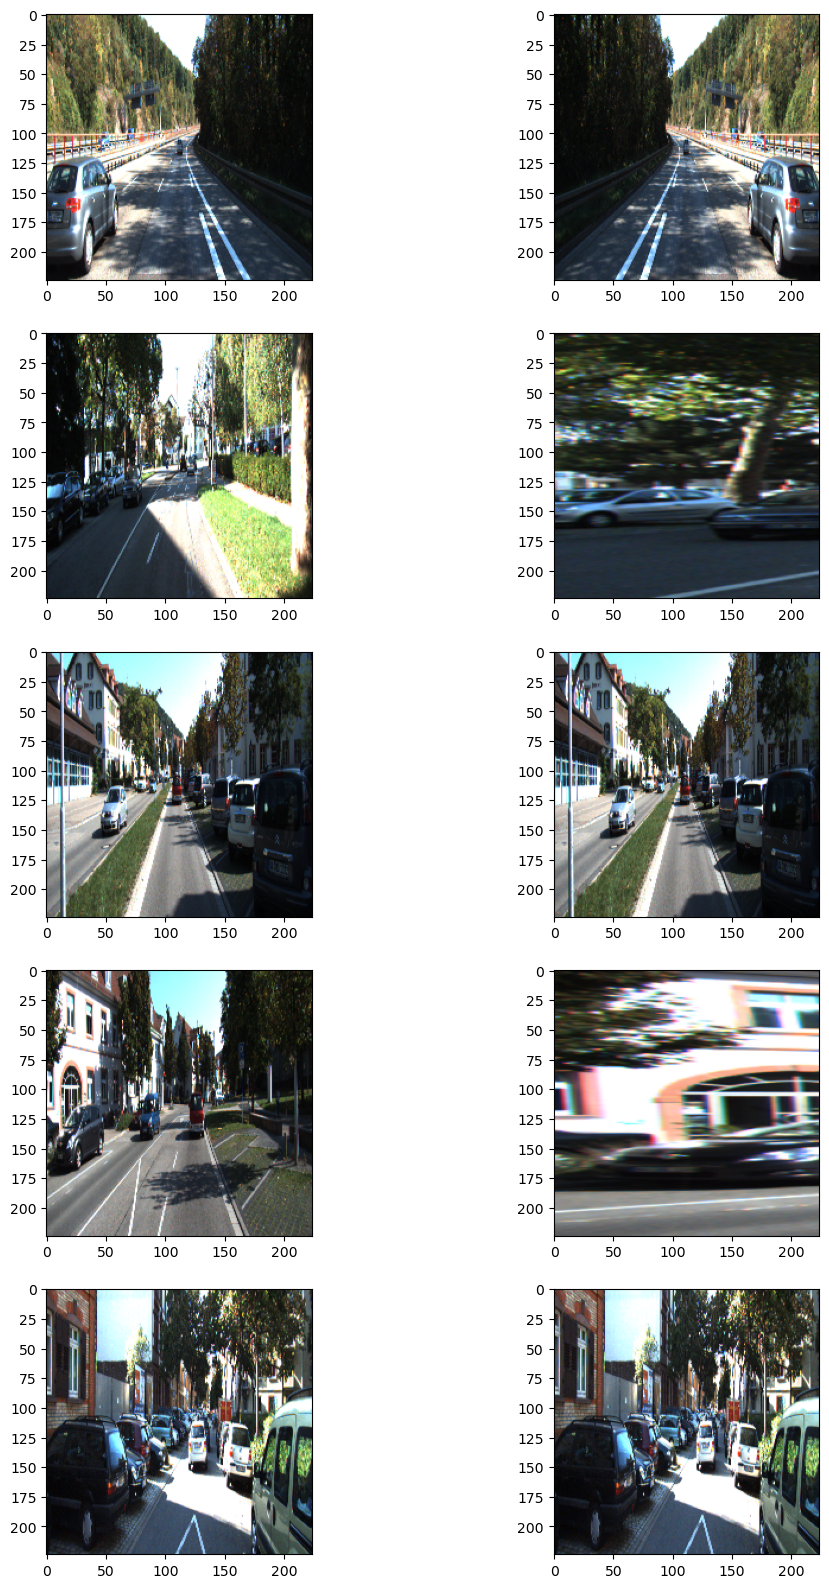

In [3]:
data_dir = os.path.join(os.getenv("HOME"), "work/semantic_segmentation/data/training")
dir_path = data_dir
augmentation_train = build_augmentation()
augmentation_test = build_augmentation(is_train=False)
input_images = glob(os.path.join(data_dir, "image_2", "*.png"))

# 훈련 데이터셋에서 5개만 가져와 augmentation을 적용해 봅시다.
plt.figure(figsize=(12, 20))
for i in range(5):
    image = imread(input_images[i])
    image_data = {"image":image}
    resized = augmentation_test(**image_data)
    processed = augmentation_train(**image_data)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(resized["image"])  # 왼쪽이 원본이미지
    plt.subplot(5, 2, 2*i+2)
    plt.imshow(processed["image"])  # 오른쪽이 augment된 이미지

plt.show()

In [4]:
from torch.utils.data import Dataset

class KittiDataset(Dataset):
    '''
    KittiDataset은 PyTorch의 Dataset을 상속받습니다.
    우리가 KittiDataset을 원하는 방식으로 preprocess하기 위해서 Dataset을 커스텀하여 사용합니다.
    '''
    def __init__(self,
                 dir_path,
                 img_size=(224, 224, 3),
                 output_size=(224, 224),
                 is_train=True,
                 augmentation=None):
        '''
        dir_path: dataset의 directory path입니다.
        img_size: preprocess에 사용할 입력이미지의 크기입니다.
        output_size: ground_truth를 만들어주기 위한 크기입니다.
        is_train: 이 Dataset이 학습용인지 테스트용인지 구분합니다.
        augmentation: 적용하길 원하는 augmentation 함수를 인자로 받습니다.
        '''
        self.dir_path = dir_path
        self.is_train = is_train
        self.augmentation = augmentation
        self.img_size = img_size
        self.output_size = output_size

        # load_dataset()을 통해 kitti dataset의 경로에서 라벨과 이미지를 확인합니다.
        self.data = self.load_dataset()

    def load_dataset(self):
        # kitti dataset에서 필요한 정보(이미지 경로 및 라벨)를 directory에서 확인하고 로드하는 함수입니다.
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))

        assert len(input_images) == len(label_images)
        data = list(zip(input_images, label_images))

        if self.is_train:
            return data[:-30]
        return data[-30:]

    def __len__(self):
        # Dataset의 length로서 전체 dataset 크기를 반환합니다.
        return len(self.data)

    def __getitem__(self, index):
        # 입력과 출력을 만듭니다.
        # 입력은 resize 및 augmentation이 적용된 input image이고
        # 출력은 semantic label입니다.
        input_img_path, output_path = self.data[index]

        _input = imread(input_img_path)
        _output = imread(output_path)

        # 특정 라벨을 이진 마스크로 변환
        _output = (_output == 7).astype(np.uint8) * 1

        data = {
            "image": _input,
            "mask": _output,
        }

        if self.augmentation:
            augmented = self.augmentation(**data)
            _input = augmented["image"] / 255.0  # Normalize
            _output = augmented["mask"]

        # 📌 target 차원 확장 (H, W) → (1, H, W)
        _output = np.expand_dims(_output, axis=0)

        return (
            torch.tensor(_input, dtype=torch.float32).permute(2, 0, 1),  # (H, W, C) → (C, H, W)
            torch.tensor(_output, dtype=torch.float32)  # (1, H, W) 형식 유지
        )

    def shuffle_data(self):
        # 한 epoch가 끝나면 실행되는 함수입니다. 학습 중인 경우에 데이터를 random shuffle합니다.
        if self.is_train:
            np.random.shuffle(self.data)

In [5]:
from torch.utils.data import DataLoader

# Augmentation 설정
augmentation = build_augmentation()
test_preproc = build_augmentation(is_train=False)

train_dataset = KittiDataset(
    data_dir,
    augmentation=augmentation,
    is_train=True
)

test_dataset = KittiDataset(
    data_dir,
    augmentation=test_preproc,
    is_train=False
)

# DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

/tmp/ipykernel_4295/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


In [6]:
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet, self).__init__()

        # Contracting Path (Encoder)
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout = nn.Dropout(0.5)

        # Expanding Path (Decoder)
        self.up6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec6 = self.double_conv(1024, 512)
        self.up7 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec7 = self.double_conv(512, 256)
        self.up8 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec8 = self.double_conv(256, 128)
        self.up9 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec9 = self.double_conv(128, 64)

        # Output layer
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        """2개의 Conv Layer로 이루어진 블록"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1)
        p2 = self.pool2(c2)
        c3 = self.enc3(p2)
        p3 = self.pool3(c3)
        c4 = self.enc4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.bottleneck(p4)
        c5 = self.dropout(c5)

        # Decoder
        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.dec6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.dec7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.dec8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.dec9(u9)

        # Output
        output = torch.sigmoid(self.final(c9))
        return output

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNetPlusPlus(nn.Module):
    # 수정 1: deep_supervision을 인자로 받고, 초기값(default)을 설정해야 합니다.
    def __init__(self, input_channels=3, output_channels=1, deep_supervision=False):
        super(UNetPlusPlus, self).__init__() # super().__init__() 도 가능합니다.
        
        # 수정 2: 인자로 받은 값을 self에 저장해야 forward에서 쓸 수 있습니다.
        self.deep_supervision = deep_supervision

        # Contracting Path (Encoder)
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout = nn.Dropout(0.5)
        
        # Upsampling Layers
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # --- U-Net++ 추가 부분: Dense Skip Connections ---
        # j=1
        self.dec1_1 = self.double_conv(64 + 128, 64)
        self.dec2_1 = self.double_conv(128 + 256, 128)
        self.dec3_1 = self.double_conv(256 + 512, 256)
        self.dec4_1 = self.double_conv(512 + 1024, 512)

        # j=2
        self.dec1_2 = self.double_conv(64*2 + 128, 64)
        self.dec2_2 = self.double_conv(128*2 + 256, 128)
        self.dec3_2 = self.double_conv(256*2 + 512, 256)

        # j=3
        self.dec1_3 = self.double_conv(64*3 + 128, 64)
        self.dec2_3 = self.double_conv(128*3 + 256, 128)

        # j=4
        self.dec1_4 = self.double_conv(64*4 + 128, 64)

        # Output layers
        self.final1 = nn.Conv2d(64, output_channels, kernel_size=1)
        self.final2 = nn.Conv2d(64, output_channels, kernel_size=1)
        self.final3 = nn.Conv2d(64, output_channels, kernel_size=1)
        self.final4 = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder (j=0)
        c1_0 = self.enc1(x)
        c2_0 = self.enc2(self.pool1(c1_0))
        c3_0 = self.enc3(self.pool2(c2_0))
        c4_0 = self.enc4(self.pool3(c3_0))
        c5_0 = self.bottleneck(self.pool4(c4_0))

        # Column j=1
        c1_1 = self.dec1_1(torch.cat([c1_0, self.up(c2_0)], 1))
        c2_1 = self.dec2_1(torch.cat([c2_0, self.up(c3_0)], 1))
        c3_1 = self.dec3_1(torch.cat([c3_0, self.up(c4_0)], 1))
        c4_1 = self.dec4_1(torch.cat([c4_0, self.up(c5_0)], 1))

        # Column j=2
        c1_2 = self.dec1_2(torch.cat([c1_0, c1_1, self.up(c2_1)], 1))
        c2_2 = self.dec2_2(torch.cat([c2_0, c2_1, self.up(c3_1)], 1))
        c3_2 = self.dec3_2(torch.cat([c3_0, c3_1, self.up(c4_1)], 1))

        # Column j=3
        c1_3 = self.dec1_3(torch.cat([c1_0, c1_1, c1_2, self.up(c2_2)], 1))
        c2_3 = self.dec2_3(torch.cat([c2_0, c2_1, c2_2, self.up(c3_2)], 1))

        # Column j=4
        c1_4 = self.dec1_4(torch.cat([c1_0, c1_1, c1_2, c1_3, self.up(c2_3)], 1))

        # Output
        if self.deep_supervision:
            # 수정 3: Deep Supervision 시에도 보통 Sigmoid를 거쳐 확률값으로 내보냅니다.
            out1 = torch.sigmoid(self.final1(c1_1))
            out2 = torch.sigmoid(self.final2(c1_2))
            out3 = torch.sigmoid(self.final3(c1_3))
            out4 = torch.sigmoid(self.final4(c1_4))
            return [out1, out2, out3, out4]
        else:
            return torch.sigmoid(self.final4(c1_4))

In [8]:

# 모델 저장 경로
model_path_unet = "./seg_model_unet.pth"

model_unet = UNet(input_channels=3, output_channels=1)
model_unet.load_state_dict(torch.load(model_path_unet, map_location=torch.device('cpu')))
model_unet.eval()  # 평가 모드로 전환

UNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc4): Sequential(
    (0): Con

In [9]:

# 모델 저장 경로
model_path_unetPlusPlus = "./seg_model_unet++.pth"

model_unetPlusPlus = UNetPlusPlus(input_channels=3, output_channels=1)
model_unetPlusPlus.load_state_dict(torch.load(model_path_unetPlusPlus, map_location=torch.device('cpu')))
model_unetPlusPlus.eval()  # 평가 모드로 전환

UNetPlusPlus(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc4): Sequential(
    

In [10]:
def calculate_iou_score(target, prediction):
    if target.shape != prediction.shape:
        prediction = resize(prediction, target.shape, mode='constant', preserve_range=True).astype(np.uint8)

    intersection = np.logical_and(target, prediction).sum() # intersection을 구하는 코드를 작성해주세요.
    union = np.logical_or(target, prediction).sum() # intersection을 구하는 코드를 작성해주세요.
    iou_score = intersection / (union + 1e-7)  # iou 스코어를 구하되 결과값을 float로 만들어주세요!
    print(f"IoU : {iou_score:.6f}\t\t\t ", end="")
    return iou_score

import numpy as np

def get_roi_iou(target, prediction):
    if target is None: return 0.0
    
    # 1. 입력된 이미지(원본 크기)의 H, W를 가져옴
    H, W = target.shape[:2]
    
    # 2. 고정 수치 대신 '비율(%)'을 사용하여 좌표 계산
    # 예: 하단 40% 영역, 좌측 45% 폭, 우측 45% 폭
    y_start = int(H * 0.6)      # 상단 60% 제외 (하단만 추출)
    x_left_end = int(W * 0.45)   # 왼쪽에서 45% 지점
    x_right_start = int(W * 0.55) # 오른쪽 45% 지점 (중앙 10% 제외)

    # 3. ROI 영역 추출
    # 좌측 하단 삼각형 구역
    roi_target_left = target[y_start:H, 0:x_left_end]
    roi_pred_left = prediction[y_start:H, 0:x_left_end]
    
    # 우측 하단 삼각형 구역
    roi_target_right = target[y_start:H, x_right_start:W]
    roi_pred_right = prediction[y_start:H, x_right_start:W]

    # 4. 두 구역을 합쳐서 IoU 계산
    roi_target = np.concatenate([roi_target_left.flatten(), roi_target_right.flatten()])
    roi_pred = np.concatenate([roi_pred_left.flatten(), roi_pred_right.flatten()])

    return calculate_iou_score(roi_target, roi_pred)
    

In [11]:
def get_output(model, preproc, image_path, output_path, label_path=None, sub_model=None):
    origin_img = imread(image_path)
    data = {"image": origin_img}
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32)
    input_tensor = input_tensor.permute(2, 0, 1).unsqueeze(0)

    model.eval()
    sub_model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        sub_output = sub_model(input_tensor)
    # forward 내부 코드 수정 제안
    prediction_np = (output[0].squeeze().cpu().numpy() > 0.5).astype(np.uint8)
    
    # 1. 컬러 마스크 생성 (예: 형광 초록 - R:0, G:255, B:0)
    color_mask = np.zeros((prediction_np.shape[0], prediction_np.shape[1], 4), dtype=np.uint8)
    color_mask[prediction_np > 0] = [255, 0, 0, 160] # 빨간색 + 투명도(160/255)
    
    # 2. PIL 이미지로 변환
    prediction_color = Image.fromarray(color_mask, 'RGBA').resize((origin_img.shape[1], origin_img.shape[0]))

    # 3. 합성 (배경 위에 컬러 마스크를 덮어씀)
    background = Image.fromarray(origin_img).convert('RGBA')
    blended = Image.alpha_composite(background, prediction_color)

    final_pred = (np.array(prediction_color.convert('L')) > 0).astype(np.uint8)
    # prediction = (output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255
    # prediction = Image.fromarray(prediction).convert('L')

    # background = Image.fromarray(origin_img).convert('RGBA')
    # prediction_resized = prediction.resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
    # blended = Image.blend(background, prediction_resized, alpha=0.5)

    blended.save(output_path)

    sub_output_path = output_path.replace(".png", "_sub.png")
    sub_prediction_np = (sub_output[0].squeeze().cpu().numpy() > 0.5).astype(np.uint8)

    
    # 1. 컬러 마스크 생성 (예: 형광 초록 - R:0, G:255, B:0)
    sub_color_mask = np.zeros((sub_prediction_np.shape[0], sub_prediction_np.shape[1], 4), dtype=np.uint8)
    sub_color_mask[sub_prediction_np > 0] = [ 0, 255, 0, 160] # 빨간색 + 투명도(160/255)
    
    # 2. PIL 이미지로 
    sub_prediction_color = Image.fromarray(sub_color_mask, 'RGBA').resize((origin_img.shape[1], origin_img.shape[0]))
    
    # 3. 합성 (배경 위에 컬러 마스크를 덮어씀)
    sub_background = Image.fromarray(origin_img).convert('RGBA')
    sub_blended = Image.alpha_composite(sub_background, sub_prediction_color)# sub_prediction = Image.fromarray(sub_prediction).convert('L')

    # sub_prediction = (sub_output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255
    # sub_background = Image.fromarray(origin_img).convert('RGBA')
    # sub_prediction_resized = sub_prediction.resize((origin_img.shape[1], os=0.5)

    
    final_sub_pred = (np.array(sub_prediction_color.convert('L')) > 0).astype(np.uint8)
    
    sub_blended.save(sub_output_path)
    # PIL 객체를 numpy로 변환
    img_np = np.array(blended)
    sub_img_np = np.array(sub_blended)

    
    plt.figure(figsize=(12, 6))

    # 왼쪽: 원본 이미지
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img_np)
    plt.axis('off')

    # 오른쪽: 예측된 마스크 (U-Net++ 결과)
    plt.subplot(1, 2, 2)
    plt.title("Predicted Mask (U-Net++)")
    plt.imshow(sub_img_np )
    # plt.axis('off')
    

    plt.tight_layout()
    plt.show()
    
    # 시각화
    # plt.imshow(img_np)
    # plt.show()

    target = None
    if label_path:
        label_img = imread(label_path)
        label_data = {"image": label_img}
        label_processed = preproc(**label_data)["image"]
        target = (label_processed == 7).astype(np.uint8) * 1

    return blended, final_pred, sub_blended, final_sub_pred, target

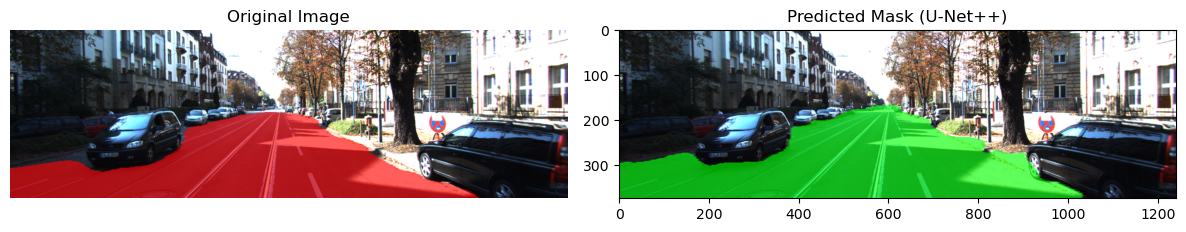

IoU : 0.041931			 IoU : 0.045054			 대비 값 :0.003124, Unet++
IoU : 0.000000			 IoU : 0.000000			 roi 대비 값 :0.000000, Unet


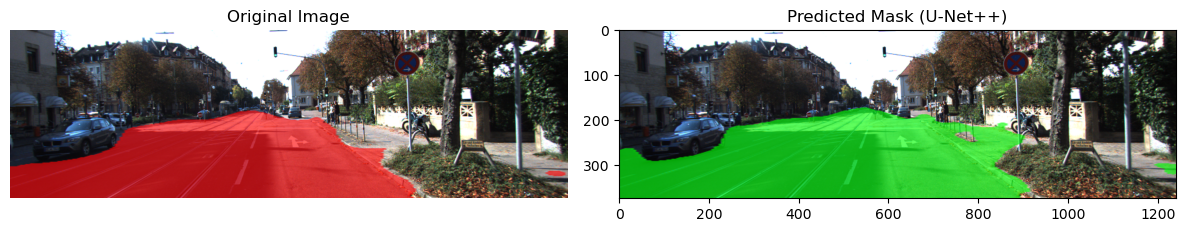

IoU : 0.043564			 IoU : 0.044189			 대비 값 :0.000625, Unet++
IoU : 0.000000			 IoU : 0.000000			 roi 대비 값 :0.000000, Unet


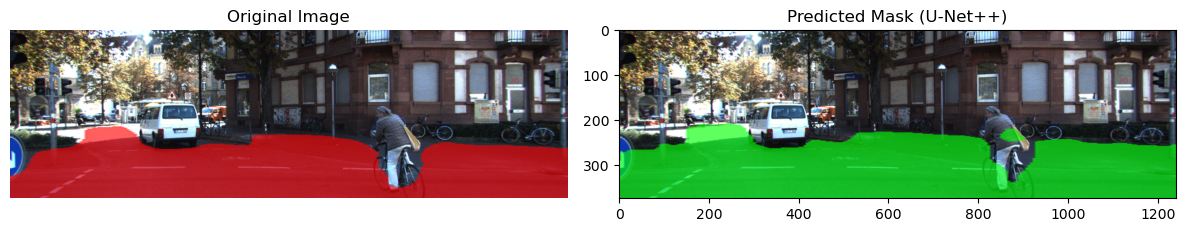

IoU : 0.041488			 IoU : 0.042217			 대비 값 :0.000729, Unet++
IoU : 0.033984			 IoU : 0.078390			 roi 대비 값 :-0.044406, Unet++


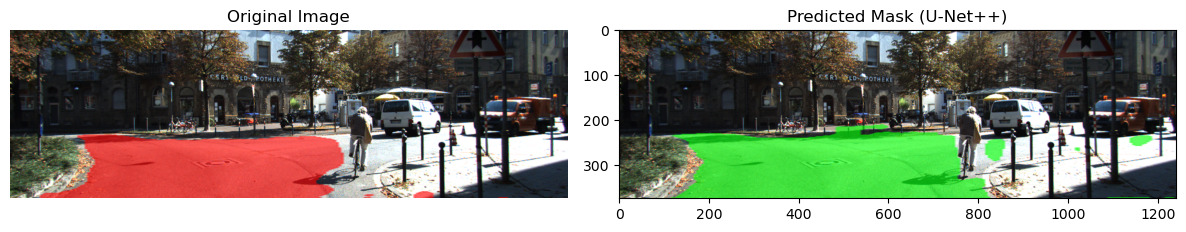

IoU : 0.032424			 IoU : 0.037157			 대비 값 :0.004733, Unet++
IoU : 0.000000			 IoU : 0.000000			 roi 대비 값 :0.000000, Unet


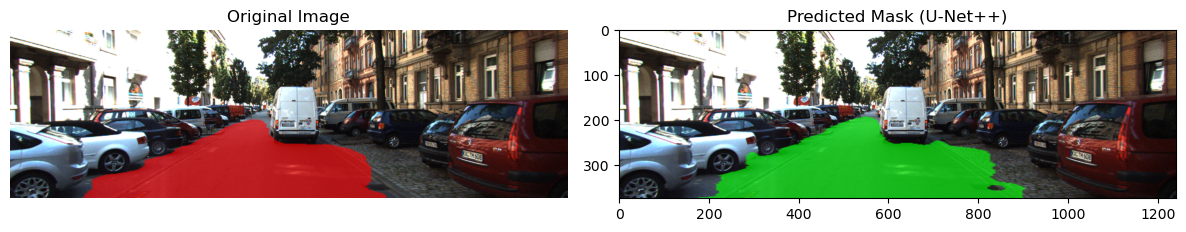

IoU : 0.043558			 IoU : 0.045851			 대비 값 :0.002292, Unet++
IoU : 0.000000			 IoU : 0.000000			 roi 대비 값 :0.000000, Unet


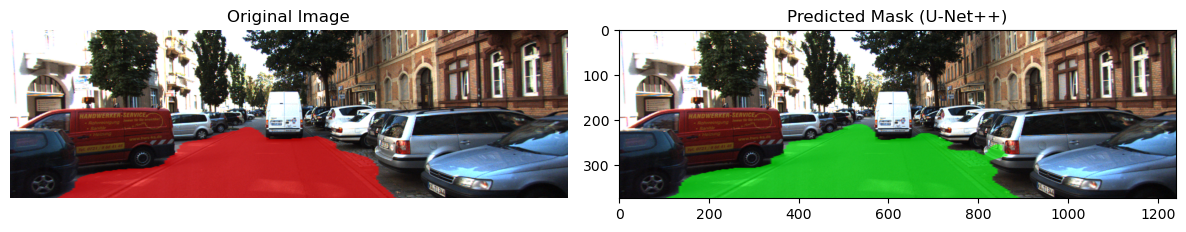

IoU : 0.046256			 IoU : 0.046407			 대비 값 :0.000151, Unet++
IoU : 0.000000			 IoU : 0.000000			 roi 대비 값 :0.000000, Unet


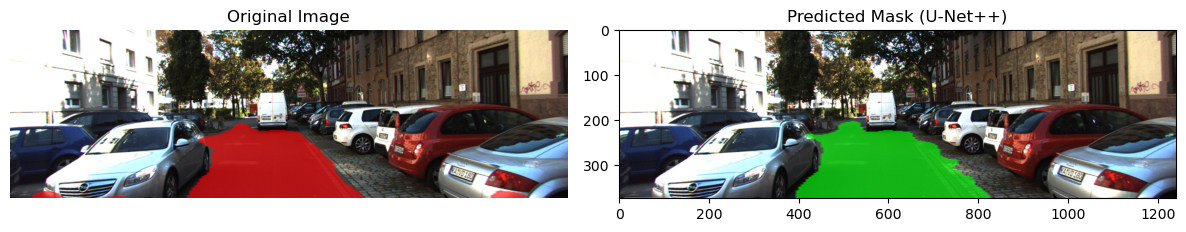

IoU : 0.045591			 IoU : 0.045658			 대비 값 :0.000067, Unet++
IoU : 0.000000			 IoU : 0.000000			 roi 대비 값 :0.000000, Unet


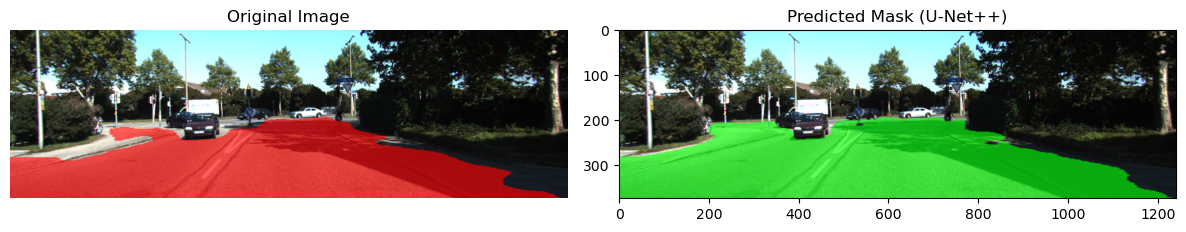

IoU : 0.042376			 IoU : 0.043751			 대비 값 :0.001376, Unet++
IoU : 0.000000			 IoU : 0.000000			 roi 대비 값 :0.000000, Unet


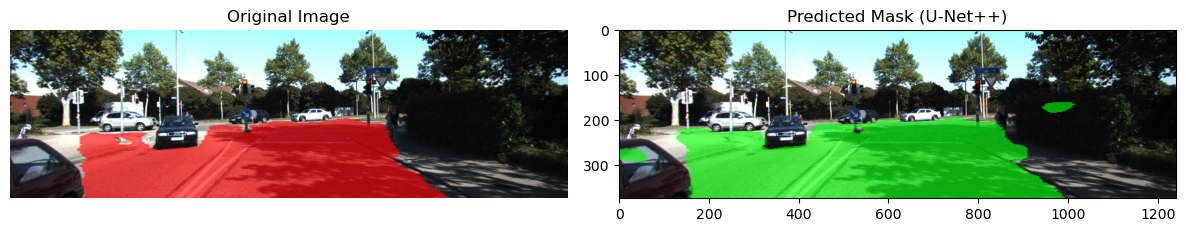

IoU : 0.043085			 IoU : 0.045506			 대비 값 :0.002421, Unet++
IoU : 0.000000			 IoU : 0.028465			 roi 대비 값 :-0.028465, Unet++


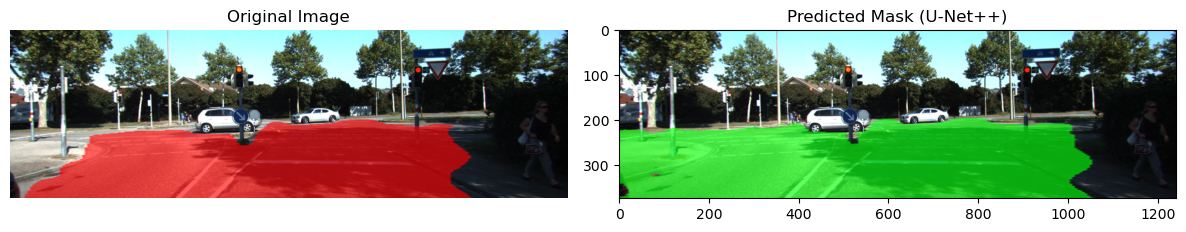

IoU : 0.041336			 IoU : 0.044296			 대비 값 :0.002959, Unet++
IoU : 0.000000			 IoU : 0.008261			 roi 대비 값 :-0.008261, Unet++


In [12]:

def score_condition(iou_score, sub_iou_score): 
    if sub_iou_score - iou_score > 0 :
        return "Unet++"
    else :
        return "Unet"
        
for i in range(10):
    # 완성한 뒤에는 시각화한 결과를 눈으로 확인해봅시다!
    #i = 1    # i값을 바꾸면 테스트용 파일이 달라집니다.
    output, prediction, sub_output, sub_prediction, target = get_output(
         model_unet,
         test_preproc,
         image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
         output_path=dir_path + f'/result_{str(i).zfill(3)}.png',
         label_path=dir_path + f'/semantic/00{str(i).zfill(4)}_10.png',
         sub_model = model_unetPlusPlus
     )
    
    iou_score = calculate_iou_score(target, prediction)
    sub_iou_score = calculate_iou_score(target, sub_prediction)
    
    print(f"대비 값 :{sub_iou_score - iou_score:2f}, {score_condition(iou_score, sub_iou_score)}")
    
    roi_iou_score = get_roi_iou(target, prediction)
    sub_roi_iou_score =get_roi_iou(target, sub_prediction)
    print(f"roi 대비 값 :{roi_iou_score - sub_roi_iou_score:2f}, {score_condition(roi_iou_score, sub_roi_iou_score)}") 
    

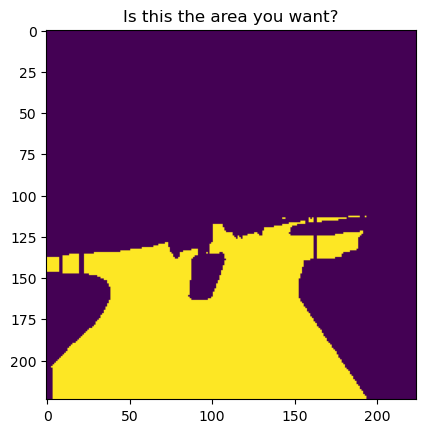

In [13]:
import matplotlib.pyplot as plt
plt.title("Is this the area you want?")
plt.imshow(target) 
plt.show()